# NOTEBOOK: K-Means Clustering

 Goal: Implement and evaluate K-Means Clustering

## Setup

In [19]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader
from src.eda import (
    analyze_data
)
from src.preprocessing import DataPreprocessor
from src.models.unsupervised import SKLearnKMeans
from src.models.unsupervised import SKLearnPCA

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data & Explore

In [20]:
X = data_loader.load_customer_segmentation()

analyze_data(X, show_stats=True)

DATA ANALYSIS

Dataset shape: 200 rows × 3 columns

Data types:
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

✓ No missing values found

Numerical columns (3):
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Categorical columns (0):
[]

Numerical features statistics:
              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000


{'numerical_cols': ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
 'categorical_cols': [],
 'missing_summary': Empty DataFrame
 Columns: [Missing_Count, Missing_Percent]
 Index: []}

## Preprocess Data

In [21]:
preprocessor = DataPreprocessor(scale=True, encode_categorical=True) # Must scale for distance-based models
X_proc = preprocessor.fit_transform(X)


DataPreprocessor: fit_transform

1. Column types:
   Numerical: 3 columns
   Nominal categorical: 0 columns
   Ordinal categorical: 0 columns

2. Processing numerical columns...
   ✓ Applied median imputation

3. Processing nominal categorical columns...

4. Processing ordinal categorical columns...

6. Scaling features...
   ✓ Scaled 3 features

Final shape: 200 rows × 3 features



## Elbow Method - Find Optimal K

FINDING OPTIMAL NUMBER OF CLUSTERS

Testing k values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Method: both

k= 1: Inertia=  600.00
k= 2: Inertia=  389.39, Silhouette=0.3355
k= 3: Inertia=  295.46, Silhouette=0.3579
k= 4: Inertia=  205.23, Silhouette=0.4040
k= 5: Inertia=  169.89, Silhouette=0.4085
k= 6: Inertia=  134.35, Silhouette=0.4311
k= 7: Inertia=  121.39, Silhouette=0.4101
k= 8: Inertia=  113.73, Silhouette=0.3674
k= 9: Inertia=  102.14, Silhouette=0.3744
k=10: Inertia=   92.55, Silhouette=0.3619

💡 Elbow method suggests: k=4
💡 Silhouette method suggests: k=6 (score: 0.4311)

⚠️  Methods disagree (Elbow: k=4, Silhouette: k=6)
   → Recommending k=6 (Silhouette is more reliable)


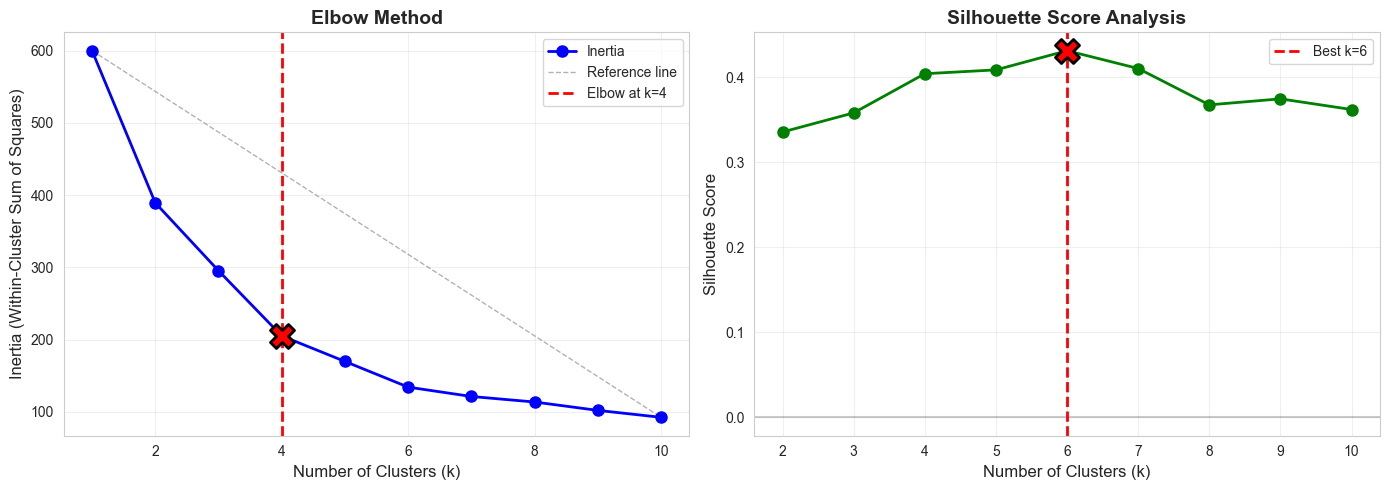

In [22]:
# Create model (doesn't need k yet)
model = SKLearnKMeans(random_state=42)

# Find optimal k automatically!
results = model.find_optimal_k(
    X_proc, 
    k_range=range(1, 11),
    method='both',  # Use both elbow and silhouette
    show_plot=True
)

# Get recommended k
optimal_k = results['optimal_k']

## Train The Model With Optimal K

In [23]:
# Get recommended k
optimal_k = results['optimal_k']

print(f"\n{'='*70}")
print(f"RECOMMENDED: k={optimal_k}")
print(f"{'='*70}")

# Train final model with optimal k
print(f"\nTraining final model with k={optimal_k}...")
final_model = SKLearnKMeans(n_clusters=optimal_k, random_state=42)
final_model.fit(X_proc)

print("✓ Model trained successfully")


RECOMMENDED: k=6

Training final model with k=6...
✓ Model trained successfully


## Clustering Evaluation

In [ ]:
print("\n" + "="*70)
print("CLUSTERING METRICS")
print("="*70)


# Silhouette Score (higher is better, range [-1, 1])
silhouette = final_model.silhouette_score(X_proc)
print(f"Silhouette Score: {silhouette:.4f}")
print("  • Range: [-1, 1]")
print("  • > 0.5: Good clustering")
print("  • 0.3-0.5: Acceptable")
print("  • < 0.3: Poor clustering")

# Inertia (lower is better)
inertia = final_model.inertia()
print(f"\nInertia (Within-cluster sum of squares): {inertia:.2f}")
print("  • Lower is better (but watch for overfitting!)")


CLUSTERING METRICS
Silhouette Score: 0.4311
  • Range: [-1, 1]
  • > 0.5: Good clustering
  • 0.3-0.5: Acceptable
  • < 0.3: Poor clustering

Inertia (Within-cluster sum of squares): 134.35
  • Lower is better (but watch for overfitting!)


## Dimensionality Reduction Visualization


PCA 2D VISUALIZATION

PCA: CLUSTER VISUALIZATION
Number of clusters: 6
PCA explains 77.6% of variance


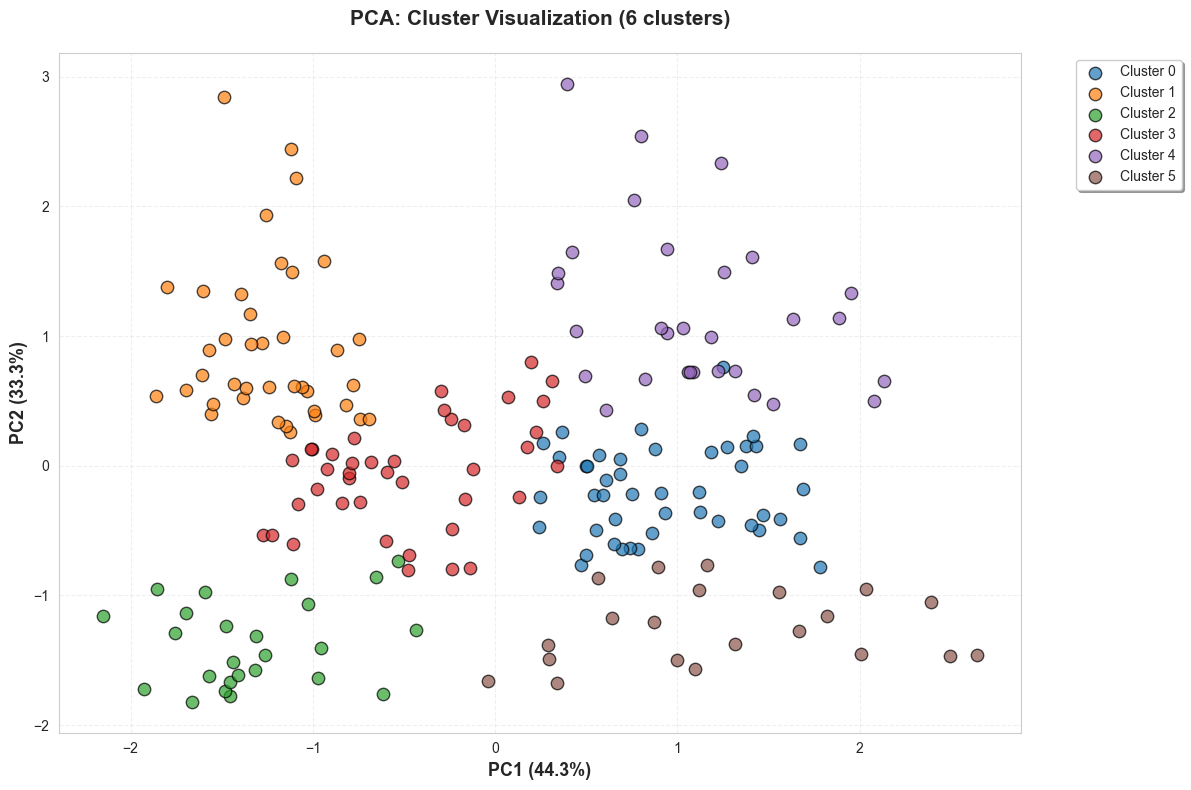


💡 Interpretation:
   • Each color = different cluster
   • Points close together = similar in feature space


In [25]:
print("\n" + "="*70)
print("PCA 2D VISUALIZATION")
print("="*70)

labels = final_model.predict(X_proc)
pca = SKLearnPCA(n_components=2)
pca.fit(X_proc)
pca.plot_clusters_2d(X_proc, labels)

## Silhouette Analysis


SILHOUETTE ANALYSIS
Overall Silhouette Score: 0.4311
Number of clusters: 6


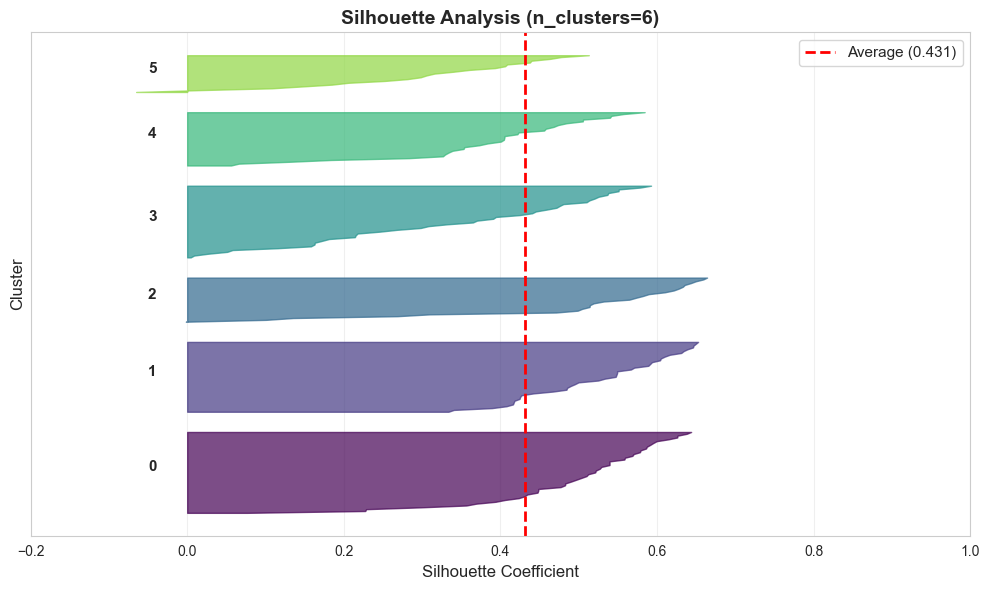


💡 How to interpret silhouette plot:
   • Width of silhouette = cluster size
   • Values > average (red line) = well-clustered samples
   • Negative values = samples likely in wrong cluster
   • Similar widths = balanced cluster sizes


In [26]:
final_model.plot_silhouette_analysis(X_proc)

# Cluster Profiling


CLUSTER PROFILES

CLUSTER 0 (n=45)
            Age  Annual Income (k$)  Spending Score (1-100)
mean  56.333333           54.266667               49.066667
std    8.453079            8.975725                6.300794

CLUSTER 1 (n=39)
            Age  Annual Income (k$)  Spending Score (1-100)
mean  32.692308           86.538462               82.128205
std    3.728650           16.312485                9.364489

CLUSTER 2 (n=25)
            Age  Annual Income (k$)  Spending Score (1-100)
mean  25.560000           26.480000               76.240000
std    5.439669            8.525061               13.562448

CLUSTER 3 (n=40)
           Age  Annual Income (k$)  Spending Score (1-100)
mean  26.12500           59.425000               44.450000
std    7.03175           10.587577               14.279176

CLUSTER 4 (n=30)
            Age  Annual Income (k$)  Spending Score (1-100)
mean  44.000000           90.133333               17.933333
std    8.081482           16.919145                9.88

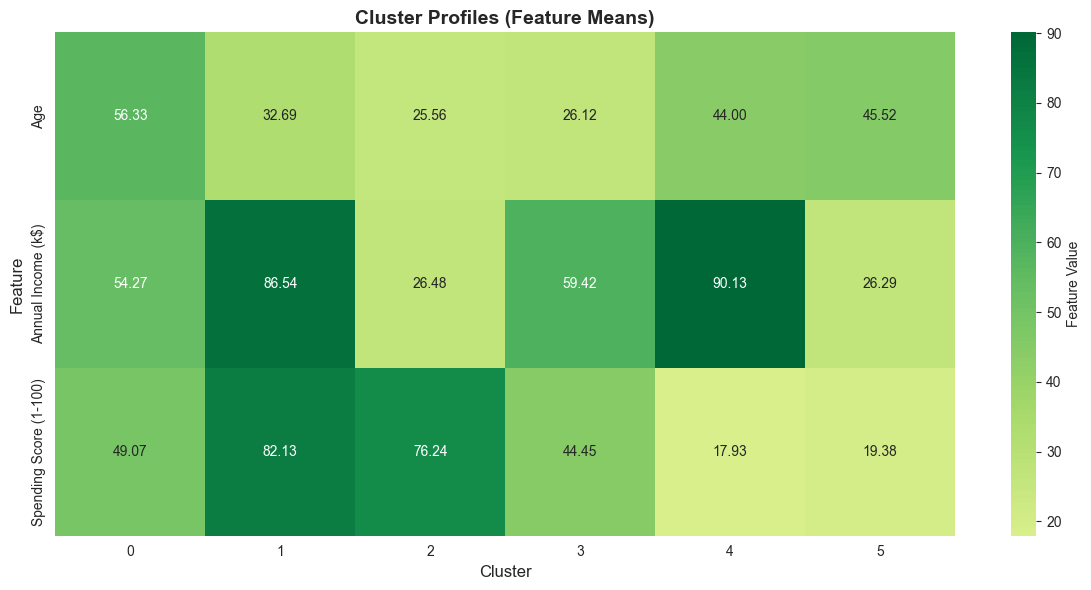


💡 Use cluster profiles to:
   • Name/interpret clusters (e.g., 'High income', 'Young users')
   • Understand what makes each cluster unique
   • Make business decisions based on cluster characteristics


In [27]:
print("\n" + "="*70)
print("CLUSTER PROFILES")
print("="*70)

# Add cluster labels to original data
X_clustered = X.copy()
X_clustered['Cluster'] = labels

# Profile each cluster
for cluster_id in range(optimal_k):
    cluster_data = X_clustered[X_clustered['Cluster'] == cluster_id]
    
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id} (n={len(cluster_data)})")
    print(f"{'='*70}")
    print(cluster_data.drop('Cluster', axis=1).describe().loc[['mean', 'std']])

# Visualize cluster profiles
feature_cols = [col for col in X_clustered.columns if col != 'Cluster']
cluster_means = X_clustered.groupby('Cluster')[feature_cols].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
           cbar_kws={'label': 'Feature Value'})
plt.title('Cluster Profiles (Feature Means)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\n💡 Use cluster profiles to:")
print("   • Name/interpret clusters (e.g., 'High income', 'Young users')")
print("   • Understand what makes each cluster unique")
print("   • Make business decisions based on cluster characteristics")

## Key Insights & Summary

In [30]:
print("\n" + "="*70)
print("KEY INSIGHTS & SUMMARY")
print("="*70)

print(f"\n✓ Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"✓ Optimal clusters: K = {optimal_k}")
print(f"✓ Silhouette Score: {silhouette:.4f}")

print(f"\n💡 K-Means Clustering:")
print(f"   • Partitioned data into {optimal_k} distinct groups")
print(f"   • Clusters are based on feature similarity")
print(f"   • Centroids represent cluster 'prototypes'")

print(f"\n💡 When to use K-Means:")
print(f"   • Spherical/globular clusters expected")
print(f"   • Approximately equal-sized clusters")
print(f"   • Fast and scalable")
print(f"   • K is known or can be estimated")

print(f"\n💡 Limitations:")
print(f"   • Assumes spherical clusters")
print(f"   • Sensitive to outliers")
print(f"   • Requires specifying K in advance")
print(f"   • Struggles with non-convex shapes")

print(f"\n💡 Next steps:")
print(f"   • Use cluster assignments for segmentation")
print(f"   • Profile clusters for business insights")
print(f"   • Try DBSCAN if you have noise/outliers")
print(f"   • Try Hierarchical if you want cluster hierarchy")


KEY INSIGHTS & SUMMARY

✓ Dataset: 200 samples, 3 features
✓ Optimal clusters: K = 6
✓ Silhouette Score: 0.4311

💡 K-Means Clustering:
   • Partitioned data into 6 distinct groups
   • Clusters are based on feature similarity
   • Centroids represent cluster 'prototypes'

💡 When to use K-Means:
   • Spherical/globular clusters expected
   • Approximately equal-sized clusters
   • Fast and scalable
   • K is known or can be estimated

💡 Limitations:
   • Assumes spherical clusters
   • Sensitive to outliers
   • Requires specifying K in advance
   • Struggles with non-convex shapes

💡 Next steps:
   • Use cluster assignments for segmentation
   • Profile clusters for business insights
   • Try DBSCAN if you have noise/outliers
   • Try Hierarchical if you want cluster hierarchy
